---
title: "Untitled"
output: html_document
date: "2025-10-07"
---



In [ ]:
knitr::opts_chunk$set(echo = TRUE)



## Loading packages



In [20]:
library(ggplot2)
library(ggrepel)
library(ggpubr)
library(stringr)
library(MASS)
library(RColorBrewer)
library(DESeq2)
library(viridis)
library(ggpointdensity)
library(tidyverse)
library(data.table)
library(pheatmap)
library(ComplexHeatmap)
library(UpSetR)
library(readxl)
library(ggsci)
library(ggpointdensity)
library(edgeR)
library(ggprism)
library(ragg)
theme_set(theme_classic(base_size = 15))

personal_path = "/fh/working/sun_w/sshen/MorPhiC"
path = "/fh/fast/sun_w/MorPhiC/data/MorPhiC_exchange_experiment/"
dat_path = file.path(path, "DRACC-processed/UCSF_exchange_experiment_DRACC_processed_August205/Tables")


In [21]:
# Storey q-values and post-DE CPM filtering for all limma-voom DE tables.
if (!requireNamespace("qvalue", quietly = TRUE)) {
  stop("The qvalue package is required. Install it with BiocManager::install('qvalue').")
}

filter_by_max_mean_cpm <- function(tt, min_cpm = 1) {
  stopifnot("max_mean_CPM" %in% colnames(tt))
  tt[is.finite(tt$max_mean_CPM) & tt$max_mean_CPM >= min_cpm, , drop = FALSE]
}

add_qvalue_and_cpm <- function(tt, counts, group = NULL, min_cpm = 1, apply_cpm_filter = TRUE) {
  stopifnot("P.Value" %in% colnames(tt), "logFC" %in% colnames(tt))

  y_cpm <- edgeR::DGEList(counts = counts)
  y_cpm <- edgeR::calcNormFactors(y_cpm)
  cpm_mat <- edgeR::cpm(y_cpm, log = FALSE)

  if (!is.null(group)) {
    group <- droplevels(factor(group))
    stopifnot(length(group) == ncol(cpm_mat), all(table(group) > 0))
    group_mean_cpm <- sapply(levels(group), function(level) {
      rowMeans(cpm_mat[, group == level, drop = FALSE], na.rm = TRUE)
    })
    group_mean_cpm <- as.data.frame(group_mean_cpm, check.names = FALSE)
    rownames(group_mean_cpm) <- rownames(cpm_mat)
    colnames(group_mean_cpm) <- paste0("mean_CPM_", make.names(colnames(group_mean_cpm)))
    cpm_filter_value <- apply(as.matrix(group_mean_cpm), 1, max, na.rm = TRUE)

    for (metric_col in colnames(group_mean_cpm)) {
      tt[[metric_col]] <- group_mean_cpm[[metric_col]][match(rownames(tt), rownames(group_mean_cpm))]
    }
  } else {
    cpm_filter_value <- rowMeans(cpm_mat, na.rm = TRUE)
    tt$mean_CPM_all <- cpm_filter_value[match(rownames(tt), names(cpm_filter_value))]
  }

  tt$max_mean_CPM <- cpm_filter_value[match(rownames(tt), names(cpm_filter_value))]
  tt$cpm_filter_value <- tt$max_mean_CPM

  p <- tt$P.Value
  keep_p <- is.finite(p) & p >= 0 & p <= 1
  tt$qvalue <- NA_real_
  tt$local_fdr <- NA_real_
  tt$pi0_storey <- NA_real_
  tt$pi0_lambda_0_5 <- NA_real_

  if (any(keep_p)) {
    p_keep <- p[keep_p]
    qvalue_fit <- qvalue::qvalue(p_keep)
    tt$qvalue[keep_p] <- qvalue_fit$qvalues
    tt$local_fdr[keep_p] <- qvalue_fit$lfdr
    tt$pi0_storey[keep_p] <- qvalue_fit$pi0
    tt$pi0_lambda_0_5[keep_p] <- min(1, max(0, 2 * mean(p_keep > 0.5)))
  }

  if (exists("gene_info") && "q75" %in% colnames(gene_info)) {
    tt$q75 <- gene_info$q75[match(rownames(tt), rownames(gene_info))]
    tt$q75_pass <- is.finite(tt$q75) & tt$q75 > 0
  } else {
    tt$q75_pass <- TRUE
  }
  tt$threshold <- tt$q75_pass &
    !is.na(tt$qvalue) & tt$qvalue < 0.05 &
    is.finite(tt$logFC) & abs(tt$logFC) > 1 &
    is.finite(tt$max_mean_CPM) & tt$max_mean_CPM >= min_cpm

  if (apply_cpm_filter) {
    tt <- filter_by_max_mean_cpm(tt, min_cpm = min_cpm)
  }
  tt[order(tt$qvalue, na.last = TRUE), , drop = FALSE]
}

add_qvalue_from_pvalue <- function(tt) {
  if ("qvalue" %in% colnames(tt) || !"P.Value" %in% colnames(tt)) {
    return(tt)
  }

  p <- tt$P.Value
  keep_p <- is.finite(p) & p >= 0 & p <= 1
  tt$qvalue <- NA_real_
  tt$local_fdr <- NA_real_
  tt$pi0_storey <- NA_real_
  tt$pi0_lambda_0_5 <- NA_real_

  if (any(keep_p)) {
    p_keep <- p[keep_p]
    qvalue_fit <- qvalue::qvalue(p_keep)
    tt$qvalue[keep_p] <- qvalue_fit$qvalues
    tt$local_fdr[keep_p] <- qvalue_fit$lfdr
    tt$pi0_storey[keep_p] <- qvalue_fit$pi0
    tt$pi0_lambda_0_5[keep_p] <- min(1, max(0, 2 * mean(p_keep > 0.5)))
  }

  if (!"q75_pass" %in% colnames(tt)) {
    tt$q75_pass <- TRUE
  }
  tt$threshold <- tt$q75_pass &
    !is.na(tt$qvalue) & tt$qvalue < 0.05 &
    is.finite(tt$logFC) & abs(tt$logFC) > 1
  tt[order(tt$qvalue, na.last = TRUE), , drop = FALSE]
}

fit_limma_with_optional_duplicate_correlation <- function(v, design, block = NULL, fit_label = NULL) {
  if (is.null(block)) {
    return(limma::lmFit(v, design))
  }

  block <- droplevels(factor(block))
  stopifnot(length(block) == ncol(v$E), !anyNA(block))
  block_counts <- table(block)
  repeated_blocks <- sum(block_counts > 1)
  label <- if (is.null(fit_label) || is.na(fit_label) || fit_label == "") {
    ""
  } else {
    paste0(" for ", fit_label)
  }

  if (nlevels(block) > 1 && repeated_blocks > 1) {
    corfit <- limma::duplicateCorrelation(v, design, block = block)
    message(sprintf("Estimated duplicate-correlation%s: %.3f", label, corfit$consensus))
    return(limma::lmFit(v, design, block = block, correlation = corfit$consensus))
  }

  message(sprintf(
    "Skipping duplicate-correlation%s: only %d repeated clone/block level(s).",
    label,
    repeated_blocks
  ))
  limma::lmFit(v, design)
}

fit_limma_group_model <- function(counts, group, block = NULL, fit_label = NULL) {
  group <- factor(group, levels = c("WT", "KO"))
  stopifnot(ncol(counts) == length(group), all(table(group) > 0))
  design <- model.matrix(~ 0 + group)
  colnames(design) <- c("WT", "KO")

  y <- edgeR::DGEList(counts)
  y <- edgeR::calcNormFactors(y)
  v <- limma::voom(y, design, plot = FALSE)
  fit <- fit_limma_with_optional_duplicate_correlation(v, design, block = block, fit_label = fit_label)
  contrast <- limma::makeContrasts(KOvsWT = KO - WT, levels = design)
  fit <- limma::eBayes(limma::contrasts.fit(fit, contrast))
  list(fit = fit, design = design, voom = v)
}



## Read in meta data



In [22]:
meta = fread(file.path(personal_path, "UCSF_meta_data.tsv"), data.table = FALSE)
dim(meta)
meta[1:2, ]
names(meta)
names(meta)[apply(meta, 2, \(x) any(is.na(x)))]
library(dplyr)

meta$KO_WT = "WT"
meta$KO_WT[meta$Condition == "full knockdown"] = "KO"
meta$KO_WT[meta$Condition == "degron plus IAA"] = "KO"
meta$KO_WT[meta$Condition == "CRISPRi plus guide plus Dox"] = "KO"



[1] 42  5

,Name,Center,Replicate,Condition,Dcondition
,<chr>,<chr>,<int>,<chr>,<chr>
1,MSK_Clone_K04_Rep_2,MSK,2,full knockdown,MSK_Clone_K04
2,KOLF_Parent__Plus_Dox_Rep_2,UCSF,2,parent line control plus dox,KOLF_Parent_ Plus_Dox


[1] "Name"       "Center"     "Replicate"  "Condition"  "Dcondition"

character(0)

In [23]:
meta[meta$Center == "NorthWestern", ]

,Name,Center,Replicate,Condition,Dcondition,KO_WT
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
3,NW_OSTIR_NKX2_1_Plus_IAA_Rep_1,NorthWestern,1,degron plus IAA,NW_OSTIR_NKX2_1_Plus_IAA,KO
4,NW_OSTIR_NKX2_1_Plus_DMSO_Rep_1,NorthWestern,1,degron plus DMSO,NW_OSTIR_NKX2_1_Plus_DMSO,WT
5,NW_OSTIR_NKX2_1_Plus_DMSO_Rep_3,NorthWestern,3,degron plus DMSO,NW_OSTIR_NKX2_1_Plus_DMSO,WT
8,NW_OSTIR_Rep_3,NorthWestern,3,no degron control plus IAA,NW_OSTIR,WT
12,NW_OSTIR_NKX2_1_Plus_IAA_Rep_2,NorthWestern,2,degron plus IAA,NW_OSTIR_NKX2_1_Plus_IAA,KO
23,NW_OSTIR_Rep_1,NorthWestern,1,no degron control plus IAA,NW_OSTIR,WT
25,NW_OSTIR_NKX2_1_Plus_IAA_Rep_3,NorthWestern,3,degron plus IAA,NW_OSTIR_NKX2_1_Plus_IAA,KO
26,NW_OSTIR_Rep_2,NorthWestern,2,no degron control plus IAA,NW_OSTIR,WT
35,NW_OSTIR_NKX2_1_Plus_DMSO_Rep_2,NorthWestern,2,degron plus DMSO,NW_OSTIR_NKX2_1_Plus_DMSO,WT


In [24]:
meta[meta$Center == "UCSF", ]

,Name,Center,Replicate,Condition,Dcondition,KO_WT
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
2,KOLF_Parent__Plus_Dox_Rep_2,UCSF,2,parent line control plus dox,KOLF_Parent_ Plus_Dox,WT
6,UCSF_CRISPRi_NKX2_1_guides_Plus_Dox_1,UCSF,1,CRISPRi plus guide plus Dox,UCSF_CRISPRi_NKX2_1_guides_Plus_Dox,KO
7,UCSF_CRISPRi_Rep_2,UCSF,2,CRISPRi no guide plus Dox,UCSF_CRISPRi,WT
10,KOLF_Parent__Plus_Dox_Rep_1,UCSF,1,parent line control plus dox,KOLF_Parent_ Plus_Dox,WT
14,UCSF_CRISPRi_NKX2_1_guides_No_Dox_3,UCSF,3,CRISPRi plus guide no Dox,UCSF_CRISPRi_NKX2_1_guides_No_Dox,WT
15,UCSF_CRISPRi_Rep_3,UCSF,3,CRISPRi no guide plus Dox,UCSF_CRISPRi,WT
16,UCSF_CRISPRi_NKX2_1_guides_Plus_Dox_3,UCSF,3,CRISPRi plus guide plus Dox,UCSF_CRISPRi_NKX2_1_guides_Plus_Dox,KO
18,KOLF_Parent_Plus_IAA_Rep_3,UCSF,3,parent line control plus IAA,KOLF_Parent_Plus_IAA,WT
19,UCSF_CRISPRi_NKX2_1_guides_No_Dox_1,UCSF,1,CRISPRi plus guide no Dox,UCSF_CRISPRi_NKX2_1_guides_No_Dox,WT



## Read in gene count data



In [25]:
cts = fread(file.path(dat_path, "genesCounts.csv"), data.table = FALSE)
dim(cts)
# To matrix
cts_dat = data.matrix(cts[, -1])
rownames(cts_dat) = cts$Name


[1] 38592    43



### Exclude genes without annotation



In [26]:
# Read in gene annotation
gene_anno = fread("/fh/fast/sun_w/sshen/MorPhiC/gencode_v44_primary_assembly_info.tsv")
dim(gene_anno)
cts = cts[cts$Name %in% gene_anno$ensembl_gene_id, ]
cts_dat = cts_dat[rownames(cts_dat) %in% gene_anno$ensembl_gene_id, ]


[1] 62754     8


### Discard genes whose expression is 0 in more than 75% of samples



In [27]:
gene_info = data.frame(
  apply(cts_dat, 1, min), 
  apply(cts_dat, 1, median), 
  apply(cts_dat, 1, \(x) quantile(x, probs = 0.75)), 
  apply(cts_dat, 1, max)
)
gene_info[1:2, ]
names(gene_info) = c("min", "median", "q75", "max")
summary(gene_info)
table(gene_info$q75 > 0)

# Keep the DE universe to q75-passing annotated genes. The max(mean WT CPM,
# mean KO CPM) filter is applied only after DE testing and saved separately.
w2kp = which(gene_info$q75 > 0)
cts_dat_all_annotated <- cts_dat
gene_info_all_annotated <- gene_info
cts_dat_q75 <- cts_dat[w2kp, , drop = FALSE]
gene_info_q75 <- gene_info[w2kp, , drop = FALSE]
cts_dat <- cts_dat_q75
gene_info <- gene_info_q75
cts <- cts[cts$Name %in% rownames(cts_dat), , drop = FALSE]


,apply.cts_dat..1..min.,apply.cts_dat..1..median.,apply.cts_dat..1..function.x..quantile.x..probs...0.75..,apply.cts_dat..1..max.
,<int>,<dbl>,<dbl>,<int>
ENSG00000268674,0,0,0.0,0
ENSG00000271254,15,94,129.5,243


      min               median              q75                 max        
 Min.   :     0.0   Min.   :     0.0   Min.   :     0.00   Min.   :     0  
 1st Qu.:     0.0   1st Qu.:     0.0   1st Qu.:     0.00   1st Qu.:     2  
 Median :     0.0   Median :     2.0   Median :     5.75   Median :    20  
 Mean   :   198.4   Mean   :   473.8   Mean   :   597.95   Mean   :  1194  
 3rd Qu.:    77.0   3rd Qu.:   235.1   3rd Qu.:   307.25   3rd Qu.:   627  
 Max.   :130520.0   Max.   :339405.0   Max.   :443938.75   Max.   :750048  


FALSE  TRUE 
15308 23284 


### Check read depth vs. gene expression quantile



In [28]:
library(dplyr)

# 1. Define conditions to remove
remove_conditions <- c("KOLF_Parent_ Plus_Dox", "KOLF_Parent_Plus_DMSO", "KOLF_Parent_Plus_IAA")

# 2. Filter out unwanted samples from 'meta' and sync 'cts_dat'
keep_samples <- !meta$Dcondition %in% remove_conditions
meta <- meta[keep_samples, ]
cts_dat <- cts_dat[, keep_samples]

# 3. Create a NEW column for the cleaned conditions, preserving original Dcondition
meta <- meta %>%
  mutate(new_condition = case_when(
    Dcondition %in% c("JAX_Clone_A03", "JAX_Clone_A06") ~ "KO_JAX",
    Dcondition %in% c("MSK_Clone_K03", "MSK_Clone_K04") ~ "KO_MSK",
    Dcondition == "KOLF_Parent" ~ "KO_WT",
    Dcondition == "NW_OSTIR_NKX2_1_Plus_IAA" ~ "AID_NW",
    Dcondition == "NW_OSTIR_NKX2_1_Plus_DMSO" ~ "AID_DMSO",
    Dcondition == "NW_OSTIR" ~ "AID_OsTIR1",
    Dcondition == "UCSF_CRISPRi" ~ "CRISPRi_WT",
    Dcondition == "UCSF_CRISPRi_NKX2_1_guides_No_Dox" ~ "CRISPRi_DMSO",
    Dcondition == "UCSF_CRISPRi_NKX2_1_guides_Plus_Dox" ~ "CRISPRi_UCSF",
    TRUE ~ Dcondition # Keeps any other groups (like MSK clones) exactly as they were
  ))

# 4. Run your original depth/quantile calculations on the cleaned data
meta$read_depth = colSums(cts_dat)/1e6
meta$q75 = apply(cts_dat, 2, quantile, probs = 0.75)

# 5. Reassign your colors based on the NEW column
my_colors <- c("blue", paletteer::paletteer_d("ggsci::category20_d3")[2:12])

# Trim the color palette to match the exact number of unique conditions in the new column
unique_conditions <- unique(meta$new_condition)
names(my_colors) = c("AID_OsTIR1",        "CRISPRi_WT",         "CRISPRi_DMSO",       "CRISPRi_AAVS1_DMSO", "AID_NW" ,            "AID_DMSO",           "AID_WT" ,           "KO_JAX"      ,       "KO_WT"    ,          "CRISPRi_UCSF"    ,   "KO_MSK"         ,    "CRISPRi_AAVS1"    )



### PCA for all samples



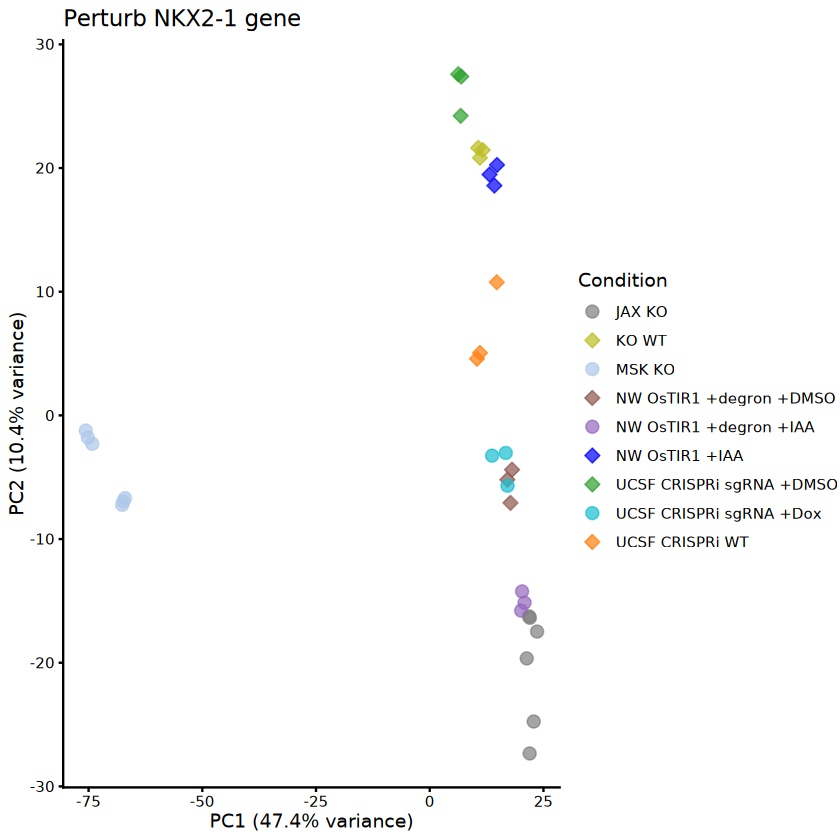

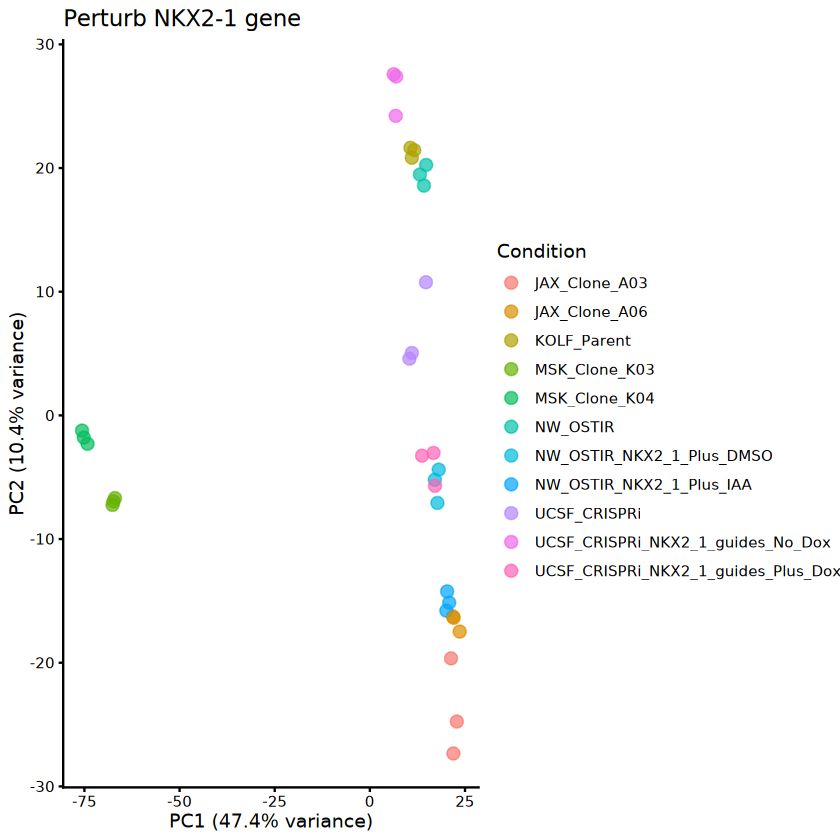

In [29]:
# PCA of all samples
y_pca <- DGEList(counts = cts_dat)
y_pca <- calcNormFactors(y_pca, method = "TMM")
logCPM_pca <- cpm(y_pca, log = TRUE)

gene_vars <- apply(logCPM_pca, 1, var)
gene_means <- apply(logCPM_pca, 1, mean)
top_genes <- order(gene_vars, decreasing = TRUE)[1:2500]
logCPM_top <- logCPM_pca[top_genes, ]

# mv_df <- data.frame(
#   Gene = rownames(logCPM_pca),
#   Mean = gene_means,
#   Variance = gene_vars,
#   Selected = rownames(logCPM_pca) %in% rownames(logCPM_top)
# )

# p_mean_var <- ggplot(mv_df, aes(x = Mean, y = Variance, color = Selected)) +
#   geom_point(alpha = 0.5, size = 1) +
#   # Add a trendline for the unselected background genes to show the baseline relationship
#   geom_smooth(data = subset(mv_df, Selected == FALSE), 
#               method = "loess", color = "blue", se = FALSE, linetype = "dashed") +
#   scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
#   theme_classic(base_size = 14) +
#   labs(
#     title = "Mean-Variance Relationship (logCPM) for NKX2-1",
#     subtitle = "Red points indicate top 2500 Highly Variable Genes",
#     x = "Mean Expression (log2-CPM)",
#     y = "Variance",
#     color = "Top 2500 HVG"
#   ) +
#   theme(legend.position = "bottom")
# 
# print(p_mean_var)

pca_input <- t(logCPM_top)
sample_pca <- prcomp(pca_input, center = TRUE, scale. = TRUE)
pc_scores = sample_pca$x
eigen_vals = sample_pca$sdev^2
pvs = round(eigen_vals[1:5]/sum(eigen_vals)*100, 1)

PC_df = data.frame(pc_scores)
PC_df = cbind(PC_df, meta)

# 1. Define the specific name mappings
label_map <- c(
  "KO_WT"         = "KO WT",
  "AID_WT"        = "NW WT",
  "AID_DMSO"      = "NW OsTIR1 +degron +DMSO",
  "AID_NW"        = "NW OsTIR1 +degron +IAA",
  "AID_OsTIR1"    = "NW OsTIR1 +IAA",
  "CRISPRi_AAVS1" = "UCSF CRISPRi AAVS1 +Dox",
  "CRISPRi_AAVS1_DMSO" = "UCSF CRISPRi AAVS1 +DMSO",
  "CRISPRi_DMSO"  = "UCSF CRISPRi sgRNA +DMSO",
  "CRISPRi_UCSF"  = "UCSF CRISPRi sgRNA +Dox",
  "CRISPRi_WT"    = "UCSF CRISPRi WT",
  "KO_JAX"        = "JAX KO",
  "KO_MSK"        = "MSK KO"
)

# 2. Apply the mapping to create a unified label column
PC_df$plot_label <- label_map[PC_df$new_condition]
PC_df = PC_df[PC_df$plot_label != "NW WT", ]
# For any conditions not in the explicit list (e.g., AID_WT, KO_WT), 
# just replace the underscores with spaces
is_na_label <- is.na(PC_df$plot_label)
PC_df$plot_label[is_na_label] <- gsub("_", " ", PC_df$new_condition[is_na_label])

# 3. Update 'my_colors' names so they match the new descriptive labels
new_color_names <- label_map[names(my_colors)]
is_na_color <- is.na(new_color_names)
new_color_names[is_na_color] <- gsub("_", " ", names(my_colors)[is_na_color])
names(my_colors) <- new_color_names

# 4. Generate a shape vector dynamically mapped to the new labels
# Assign 21 (circle) to GCM1 and 23 (diamond) to WT
shape_lookup <- ifelse(PC_df$KO_WT == "KO", 21, 23)
my_shapes <- setNames(shape_lookup, PC_df$plot_label)
my_shapes <- my_shapes[!duplicated(names(my_shapes))] # Ensure the list of shapes is unique


gPC = ggplot(PC_df, aes(x = PC1, y = PC2, color = plot_label, fill = plot_label, shape = plot_label)) +
  geom_point(size = 3, alpha = 0.7, stroke = 0.5) + 
  scale_color_manual(values = my_colors) +
  scale_fill_manual(values = my_colors) +
  scale_shape_manual(values = my_shapes) +
  labs(
    title = "Perturb NKX2-1 gene",
    x = sprintf("PC1 (%.1f%% variance)", pvs[1]),
    y = sprintf("PC2 (%.1f%% variance)", pvs[2]),
    # Use the same title for all aesthetics to keep the legend merged
    color = "Condition",
    fill  = "Condition",
    shape = "Condition"
  ) +
  theme_classic() + # Optional: Use to recreate the exact background from your image
  theme(
    legend.margin = margin(0, 0, 0, 0), 
    legend.box.just = "left", 
    legend.direction = "vertical" 
  )

print(gPC)

width_px  = 1600
height_px = round(width_px * (3/5)) 

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "NKX2-1_PCPlot_all_samples.png",sep='')),
  plot     = gPC,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300,
)

ggplot(PC_df, aes(x = PC1, y = PC2, color = Dcondition)) +
  geom_point(size = 3, alpha = 0.7, stroke = 0.5) + 
  labs(
    title = "Perturb NKX2-1 gene",
    x = sprintf("PC1 (%.1f%% variance)", pvs[1]),
    y = sprintf("PC2 (%.1f%% variance)", pvs[2]),
    # Use the same title for all aesthetics to keep the legend merged
    color = "Condition"
  ) +
  theme_classic() + # Optional: Use to recreate the exact background from your image
  theme(
    legend.margin = margin(0, 0, 0, 0), 
    legend.box.just = "left", 
    legend.direction = "vertical" 
  )


In [30]:
library(ggplot2)
library(dplyr)
library(tidyr)

# 1. Calculate total read depth in millions for each sample
total_depth_M <- colSums(cts_dat) / 1e6

# 2. Function to calculate percentiles per sample
# Note: It is usually best to filter out zeros in RNA-seq before calculating percentiles
calc_percentiles <- function(x) {
  quantile(x[x > 0], probs = c(0.75, 0.95)) 
}

# Apply across columns (samples) and transpose
sample_percentiles <- t(apply(cts_dat, 2, calc_percentiles))
colnames(sample_percentiles) <- c("P75", "P95")

# 3. Create a plotting dataframe
# Assuming you have a metadata table 'meta_dat' with a 'Group' column used for your PCA colors
qc_df <- data.frame(
  Sample = colnames(cts_dat),
  Total_Depth = total_depth_M,
  Group = PC_df$plot_label,
  ko_gene = PC_df$KO_WT
)
qc_df <- cbind(qc_df, sample_percentiles)

# 4. Pivot to long format so we can facet the plots by percentile
qc_long <- qc_df %>%
  pivot_longer(cols = starts_with("P"), 
               names_to = "Percentile", 
               values_to = "Expression_Count")

shape_lookup <- ifelse(qc_long$ko_gene == "KO", 21, 23)
my_shapes <- setNames(shape_lookup, qc_long$Group)
my_shapes <- my_shapes[!duplicated(names(my_shapes))]

# 5. Generate the faceted scatter plot
gPC = ggplot(qc_long, aes(x = Total_Depth, y = Expression_Count, color = Group, shape = Group)) +
  geom_point(size = 2, alpha = 0.8) +
  facet_wrap(~ Percentile, scales = "free_y") + # free_y allows each percentile to have its own y-axis scale
  theme_minimal() + scale_color_manual(values = my_colors) + scale_shape_manual(values = my_shapes) + 
  labs(
    title = "Expression Percentiles vs. Total Read Depth for NKX2-1",
    x = "Total Read Depth (Millions)",
    y = "Expression Count at Percentile",
    color = "Condition",
    shape = "Condition"
  )

# Save the plot
width_px  = 1800
height_px = round(width_px * (1/2))

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "NKX2-1_Check_Read_Depth.png",sep='')),
  plot     = gPC,
  device   = ragg::agg_png,
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300
)


[1] 23284    33

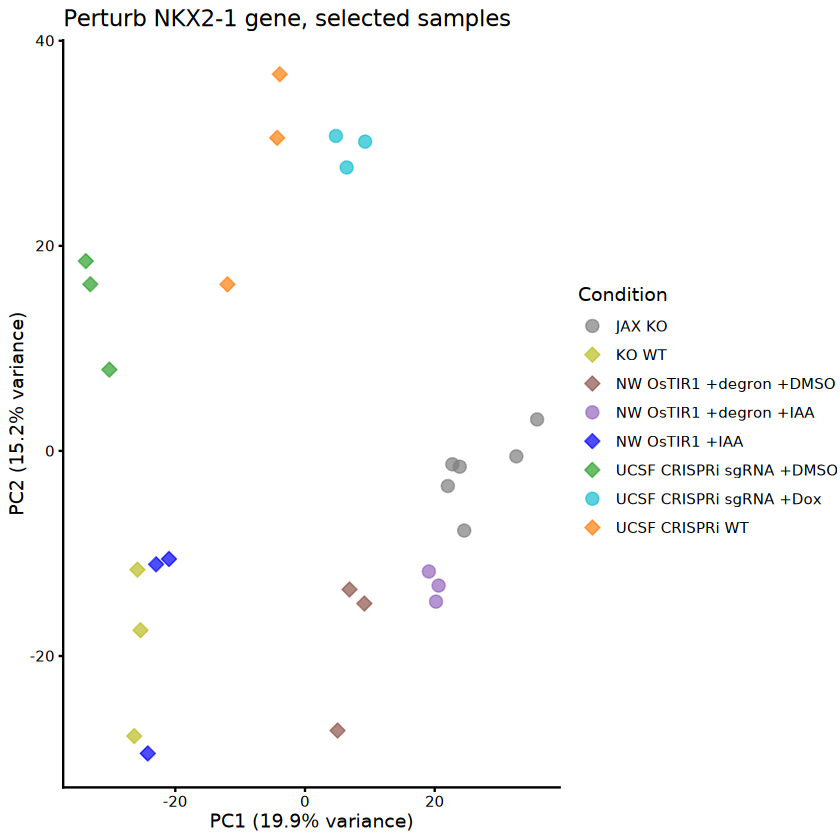

In [31]:
# PCA of all samples
cts_dat_n = cts_dat
dim(cts_dat_n)

cts_dat_n_w = cts_dat_n[, meta$Center != "MSK"]
meta_w = meta[meta$Center != "MSK", ]

y_pca <- DGEList(counts = cts_dat_n_w)
y_pca <- calcNormFactors(y_pca, method = "TMM")
logCPM_pca <- cpm(y_pca, log = TRUE)

gene_vars <- apply(logCPM_pca, 1, var)
gene_means <- apply(logCPM_pca, 1, mean)
top_genes <- order(gene_vars, decreasing = TRUE)[1:2500]
logCPM_top <- logCPM_pca[top_genes, ]

# mv_df <- data.frame(
#   Gene = rownames(logCPM_pca),
#   Mean = gene_means,
#   Variance = gene_vars,
#   Selected = rownames(logCPM_pca) %in% rownames(logCPM_top)
# )
# 
# p_mean_var <- ggplot(mv_df, aes(x = Mean, y = Variance, color = Selected)) +
#   geom_point(alpha = 0.5, size = 1) +
#   # Add a trendline for the unselected background genes to show the baseline relationship
#   geom_smooth(data = subset(mv_df, Selected == FALSE), 
#               method = "loess", color = "blue", se = FALSE, linetype = "dashed") +
#   scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
#   theme_classic(base_size = 14) +
#   labs(
#     title = "Mean-Variance Relationship (logCPM)",
#     subtitle = "Red points indicate top 2500 Highly Variable Genes",
#     x = "Mean Expression (log2-CPM)",
#     y = "Variance",
#     color = "Top 2500 HVG"
#   ) +
#   theme(legend.position = "bottom")
# 
# print(p_mean_var)


pca_input <- t(logCPM_top)
sample_pca <- prcomp(pca_input, center = TRUE, scale. = TRUE)
pc_scores = sample_pca$x
eigen_vals = sample_pca$sdev^2
pvs = round(eigen_vals[1:5]/sum(eigen_vals)*100, 1)

PC_df = data.frame(pc_scores)
PC_df = cbind(PC_df, meta_w)

# 1. Define the specific name mappings
label_map <- c(
  "KO_WT"         = "KO WT",
  "AID_WT"        = "NW WT",
  "AID_DMSO"      = "NW OsTIR1 +degron +DMSO",
  "AID_NW"        = "NW OsTIR1 +degron +IAA",
  "AID_OsTIR1"    = "NW OsTIR1 +IAA",
  "CRISPRi_AAVS1" = "UCSF CRISPRi AAVS1 +Dox",
  "CRISPRi_AAVS1_DMSO" = "UCSF CRISPRi AAVS1 +DMSO",
  "CRISPRi_DMSO"  = "UCSF CRISPRi sgRNA +DMSO",
  "CRISPRi_UCSF"  = "UCSF CRISPRi sgRNA +Dox",
  "CRISPRi_WT"    = "UCSF CRISPRi WT",
  "KO_JAX"        = "JAX KO",
  "KO_MSK"        = "MSK KO"
)

# 2. Apply the mapping to create a unified label column
PC_df$plot_label <- label_map[PC_df$new_condition]
PC_df = PC_df[PC_df$plot_label != "NW WT", ]
# For any conditions not in the explicit list (e.g., AID_WT, KO_WT), 
# just replace the underscores with spaces
is_na_label <- is.na(PC_df$plot_label)
PC_df$plot_label[is_na_label] <- gsub("_", " ", PC_df$new_condition[is_na_label])

# 3. Update 'my_colors' names so they match the new descriptive labels
new_color_names <- label_map[names(my_colors)]
is_na_color <- is.na(new_color_names)
new_color_names[is_na_color] <- gsub("_", " ", names(my_colors)[is_na_color])
names(my_colors) <- new_color_names

# 4. Generate a shape vector dynamically mapped to the new labels
# Assign 21 (circle) to GCM1 and 23 (diamond) to WT
shape_lookup <- ifelse(PC_df$KO_WT == "KO", 21, 23)
my_shapes <- setNames(shape_lookup, PC_df$plot_label)
my_shapes <- my_shapes[!duplicated(names(my_shapes))] # Ensure the list of shapes is unique


gPC = ggplot(PC_df, aes(x = PC1, y = PC2, color = plot_label, fill = plot_label, shape = plot_label)) +
  geom_point(size = 3, alpha = 0.7, stroke = 0.5) + 
  scale_color_manual(values = my_colors) +
  scale_fill_manual(values = my_colors) +
  scale_shape_manual(values = my_shapes) +
  labs(
    title = "Perturb NKX2-1 gene, selected samples",
    x = sprintf("PC1 (%.1f%% variance)", pvs[1]),
    y = sprintf("PC2 (%.1f%% variance)", pvs[2]),
    # Use the same title for all aesthetics to keep the legend merged
    color = "Condition",
    fill  = "Condition",
    shape = "Condition"
  ) +
  theme_classic() + # Optional: Use to recreate the exact background from your image
  theme(
    legend.margin = margin(0, 0, 0, 0), 
    legend.box.just = "left", 
    legend.direction = "vertical" 
  )

print(gPC)

width_px  = 1600
height_px = round(width_px * (3/5)) 

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "NKX2-1_PCPlot_no_MSK.png",sep='')),
  plot     = gPC,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300,
)



### DE analysis for UCSF and NW



In [32]:
model1 = c("NW_OSTIR_NKX2_1_Plus_IAA", "NW_OSTIR", "UCSF_CRISPRi_NKX2_1_guides_Plus_Dox", "UCSF_CRISPRi_NKX2_1_guides_No_Dox")
sample2kp = which(meta$Dcondition %in% model1)

cts_dat_m = cts_dat[,sample2kp]
meta_m    = meta[sample2kp,]
  
## Generate sample information matrix
sample_info = meta_m
  

model1 = c("UCSF_CRISPRi_NKX2_1_guides_Plus_Dox", "UCSF_CRISPRi_NKX2_1_guides_No_Dox")
sample2kp = which(meta_m$Dcondition %in% model1)
cts_dat_m_UCSF = cts_dat_m[,sample2kp]
sample_info_UCSF = sample_info[sample2kp,]

library(edgeR)
library(limma)

# ---- inputs ----
counts  <- cts_dat_m_UCSF
colData <- sample_info_UCSF
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group factor: WT vs KO ----
group <- ifelse(colData$KO_WT == "WT",
                "WT", "KO")
group <- factor(group, levels = c("WT","KO"))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- normalization + voom (quality weights optional) ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)
fitUCSF <- lmFit(v2, design2)

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitUCSF <- eBayes(contrasts.fit(fitUCSF, L2))
ttUCSF   <- topTable(fitUCSF, coef = "KOvsWT", number = Inf)
ttUCSF_before_max_mean_filter <- add_qvalue_and_cpm(ttUCSF, counts, group = group, apply_cpm_filter = FALSE)
ttUCSF <- filter_by_max_mean_cpm(ttUCSF_before_max_mean_filter, min_cpm = 1)


model1 = c("NW_OSTIR_NKX2_1_Plus_IAA", "NW_OSTIR")
sample2kp = which(meta_m$Dcondition %in% model1)
cts_dat_m_NW = cts_dat_m[,sample2kp]
sample_info_NW = sample_info[sample2kp,]

library(edgeR)
library(limma)

# ---- inputs ----
counts  <- cts_dat_m_NW
colData <- sample_info_NW
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group factor: WT vs KO ----
group <- ifelse(colData$KO_WT == "WT",
                "WT", "KO")
group <- factor(group, levels = c("WT","KO"))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- normalization + voom (quality weights optional) ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)
fitNW <- lmFit(v2, design2)

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitNW <- eBayes(contrasts.fit(fitNW, L2))
ttNW   <- topTable(fitNW, coef = "KOvsWT", number = Inf)
ttNW_before_max_mean_filter <- add_qvalue_and_cpm(ttNW, counts, group = group, apply_cpm_filter = FALSE)
ttNW <- filter_by_max_mean_cpm(ttNW_before_max_mean_filter, min_cpm = 1)

# pheatmap(cor(v2$E))




### DE analysis for NW with dmso



In [33]:
model1 = c("NW_OSTIR_NKX2_1_Plus_IAA", "NW_OSTIR_NKX2_1_Plus_DMSO", "UCSF_CRISPRi_NKX2_1_guides_Plus_Dox", "UCSF_CRISPRi_NKX2_1_guides_No_Dox")
sample2kp = which(meta$Dcondition %in% model1)

cts_dat_m = cts_dat[,sample2kp]
meta_m    = meta[sample2kp,]
  
## Generate sample information matrix
sample_info = meta_m
  


model1 = c("NW_OSTIR_NKX2_1_Plus_IAA", "NW_OSTIR_NKX2_1_Plus_DMSO")
sample2kp = which(meta_m$Dcondition %in% model1)
cts_dat_m_NW = cts_dat_m[,sample2kp]
sample_info_NW = sample_info[sample2kp,]

library(edgeR)
library(limma)

# ---- inputs ----
counts  <- cts_dat_m_NW
colData <- sample_info_NW
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group factor: WT vs KO ----
group <- ifelse(colData$KO_WT == "WT",
                "WT", "KO")
group <- factor(group, levels = c("WT","KO"))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- normalization + voom (quality weights optional) ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)
fitNW <- lmFit(v2, design2)

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitNW <- eBayes(contrasts.fit(fitNW, L2))
ttNW_dmso   <- topTable(fitNW, coef = "KOvsWT", number = Inf)
ttNW_dmso_before_max_mean_filter <- add_qvalue_and_cpm(ttNW_dmso, counts, group = group, apply_cpm_filter = FALSE)
ttNW_dmso <- filter_by_max_mean_cpm(ttNW_dmso_before_max_mean_filter, min_cpm = 1)

# pheatmap(cor(v2$E))



### DE analysis for JAX



In [34]:
model1 = c("JAX_Clone_A03", "JAX_Clone_A06", "KOLF_Parent")
sample2kp = which(meta$Dcondition %in% model1)

cts_dat_m = cts_dat[,sample2kp]
meta_m    = meta[sample2kp,]
  
## Generate sample information matrix
sample_info = meta_m
  
model1 = c("JAX_Clone_A03", "JAX_Clone_A06", "KOLF_Parent")
sample2kp = which(meta_m$Dcondition %in% model1)
cts_dat_m_JAX = cts_dat_m[,sample2kp]
sample_info_JAX = sample_info[sample2kp,]

library(edgeR)
library(limma)

# ---- inputs ----
counts  <- cts_dat_m_JAX
colData <- sample_info_JAX
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group factor: WT vs KO ----
group <- ifelse(colData$KO_WT == "WT",
                "WT", "KO")
group <- factor(group, levels = c("WT","KO"))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- block vector: KO keep clone IDs; WT each unique ----
isWT  <- group == "WT"
block <- as.character(colData$Dcondition)
block[isWT] <- paste0("WT_", seq_len(sum(isWT)))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- normalization + voom (quality weights optional) ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)

# ---- optional duplicate-correlation fit ----
fitJAX <- fit_limma_with_optional_duplicate_correlation(v2, design2, block = block, fit_label = "fitJAX")

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitJAX <- eBayes(contrasts.fit(fitJAX, L2))
ttJAX   <- topTable(fitJAX, coef = "KOvsWT", number = Inf)
ttJAX_before_max_mean_filter <- add_qvalue_and_cpm(ttJAX, counts, group = group, apply_cpm_filter = FALSE)
ttJAX <- filter_by_max_mean_cpm(ttJAX_before_max_mean_filter, min_cpm = 1)




model1 = c("MSK_Clone_K03", "KOLF_Parent")
sample2kp = which(meta$Dcondition %in% model1)

cts_dat_m = cts_dat[,sample2kp]
meta_m    = meta[sample2kp,]
  
## Generate sample information matrix
sample_info = meta_m
  
model1 = c("MSK_Clone_K03", "KOLF_Parent")
sample2kp = which(meta_m$Dcondition %in% model1)
cts_dat_m_MSK = cts_dat_m[,sample2kp]
sample_info_MSK = sample_info[sample2kp,]

library(edgeR)
library(limma)

# ---- inputs ----
counts  <- cts_dat_m_MSK
colData <- sample_info_MSK
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group factor: WT vs KO ----
group <- ifelse(colData$KO_WT == "WT",
                "WT", "KO")
group <- factor(group, levels = c("WT","KO"))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- block vector: KO keep clone IDs; WT each unique ----
isWT  <- group == "WT"
block <- as.character(colData$Dcondition)
block[isWT] <- paste0("WT_", seq_len(sum(isWT)))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- normalization + voom (quality weights optional) ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)

# ---- optional duplicate-correlation fit ----
fitMSK <- fit_limma_with_optional_duplicate_correlation(v2, design2, block = block, fit_label = "fitMSK")

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitMSK <- eBayes(contrasts.fit(fitMSK, L2))
ttMSK   <- topTable(fitMSK, coef = "KOvsWT", number = Inf)
ttMSK_before_max_mean_filter <- add_qvalue_and_cpm(ttMSK, counts, group = group, apply_cpm_filter = FALSE)
ttMSK <- filter_by_max_mean_cpm(ttMSK_before_max_mean_filter, min_cpm = 1)


Estimated duplicate-correlation for fitJAX: 0.215

Skipping duplicate-correlation for fitMSK: only 1 repeated clone/block level(s).




### Volcano plot visualization



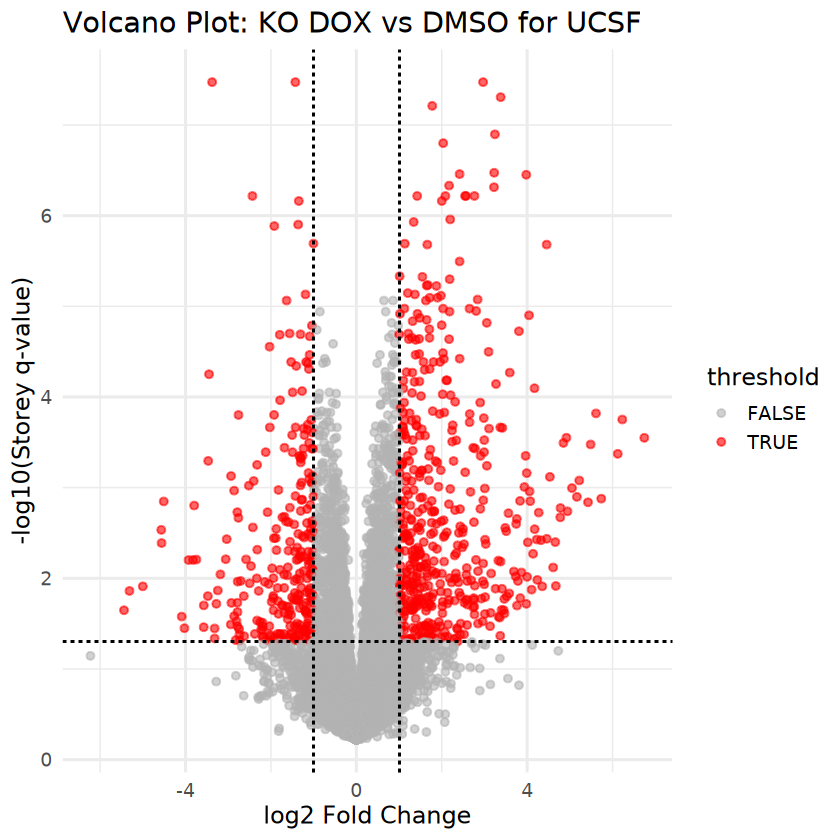

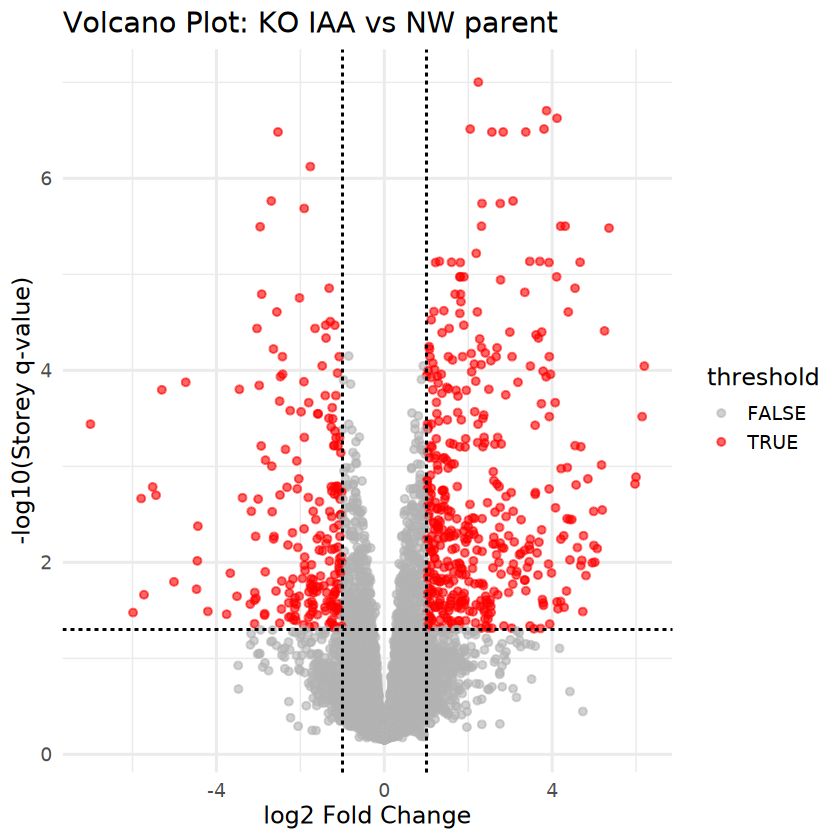

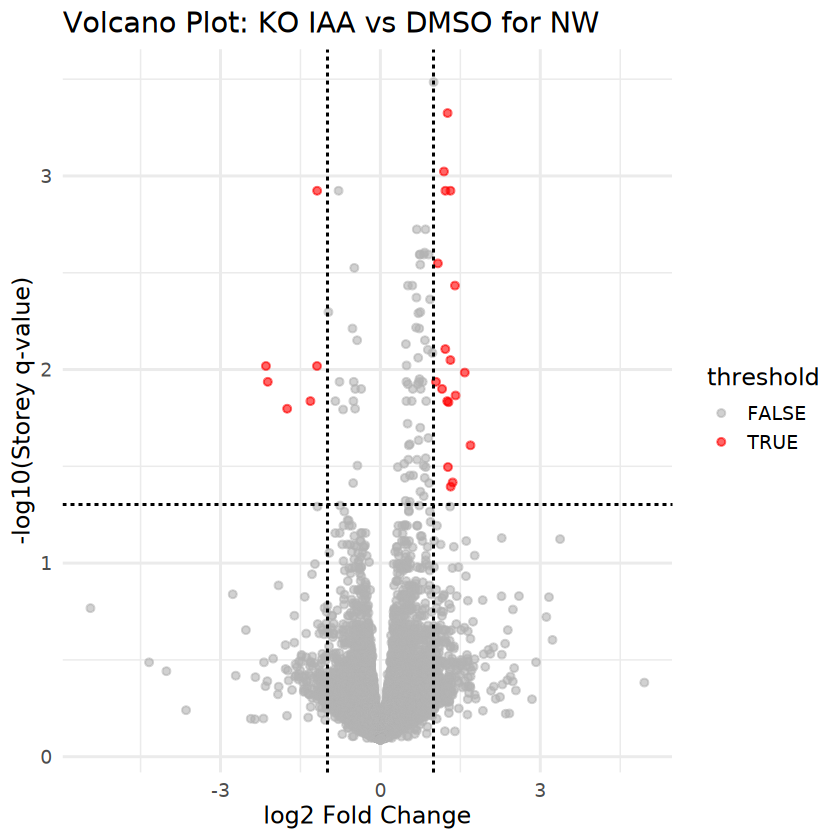

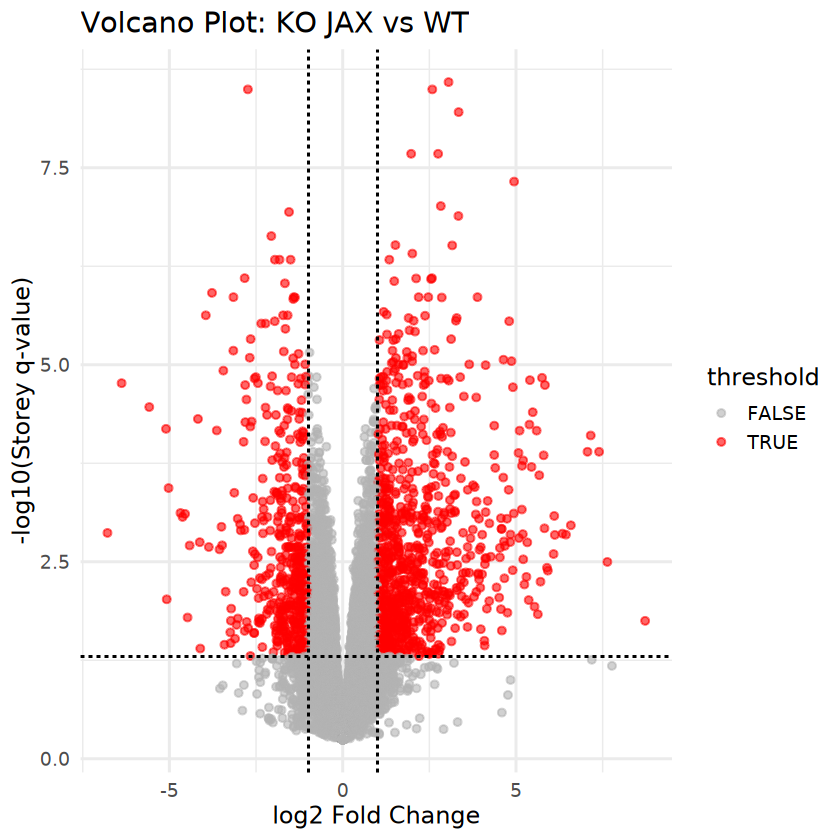

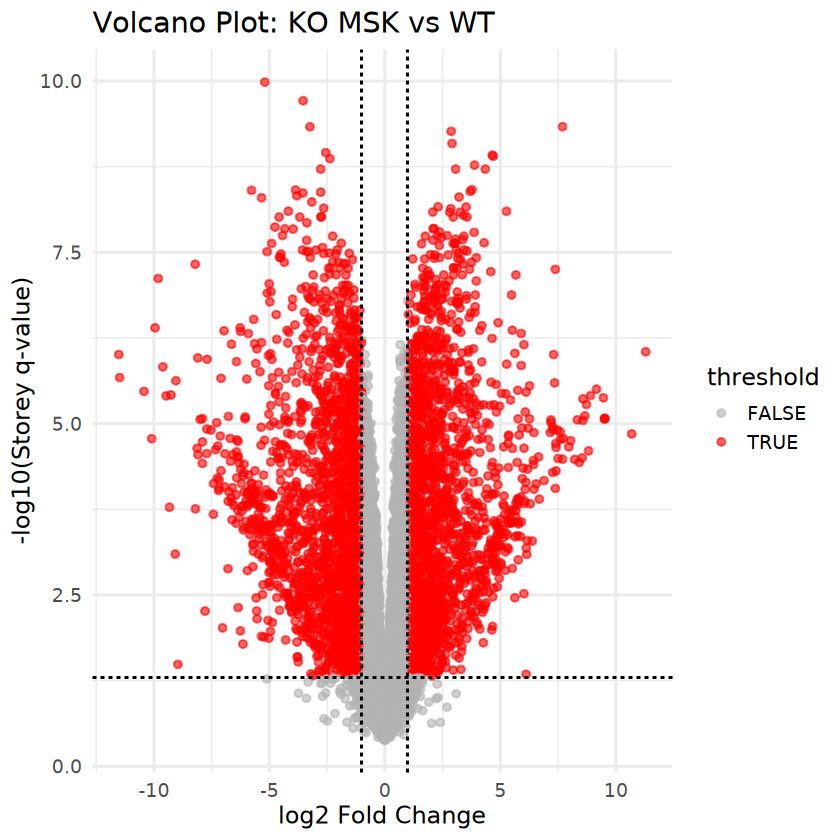

In [35]:
# Add a significance column for coloring
ttUCSF$threshold <- ttUCSF$q75_pass &
  !is.na(ttUCSF$qvalue) & ttUCSF$qvalue < 0.05 &
  is.finite(ttUCSF$logFC) & abs(ttUCSF$logFC) > 1 &
  is.finite(ttUCSF$max_mean_CPM) & ttUCSF$max_mean_CPM >= 1

p1 = ggplot(ttUCSF, aes(x = logFC, y = -log10(qvalue))) +
  geom_point(aes(color = threshold), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
  theme_minimal(base_size = 14) +
  labs(title = "Volcano Plot: KO DOX vs DMSO for UCSF",
       x = "log2 Fold Change",
       y = "-log10(Storey q-value)") +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black")

# Add a significance column for coloring
ttNW$threshold <- ttNW$q75_pass &
  !is.na(ttNW$qvalue) & ttNW$qvalue < 0.05 &
  is.finite(ttNW$logFC) & abs(ttNW$logFC) > 1 &
  is.finite(ttNW$max_mean_CPM) & ttNW$max_mean_CPM >= 1

p2 = ggplot(ttNW, aes(x = logFC, y = -log10(qvalue))) +
  geom_point(aes(color = threshold), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
  theme_minimal(base_size = 14) +
  labs(title = "Volcano Plot: KO IAA vs NW parent",
       x = "log2 Fold Change",
       y = "-log10(Storey q-value)") +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black")

# Add a significance column for coloring
ttNW_dmso$threshold <- ttNW_dmso$q75_pass &
  !is.na(ttNW_dmso$qvalue) & ttNW_dmso$qvalue < 0.05 &
  is.finite(ttNW_dmso$logFC) & abs(ttNW_dmso$logFC) > 1 &
  is.finite(ttNW_dmso$max_mean_CPM) & ttNW_dmso$max_mean_CPM >= 1

pt = ggplot(ttNW_dmso, aes(x = logFC, y = -log10(qvalue))) +
  geom_point(aes(color = threshold), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
  theme_minimal(base_size = 14) +
  labs(title = "Volcano Plot: KO IAA vs DMSO for NW",
       x = "log2 Fold Change",
       y = "-log10(Storey q-value)") +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black")


width_px  = 1920
height_px = round(width_px * (3/4)) 

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "NKX2-1_VolcanoPlot_UCSF.png",sep='')),
  plot     = p1,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300,
)
ggsave(
  filename = file.path(personal_path, paste0("/publication/", "NKX2-1_VolcanoPlot_NW.png",sep='')),
  plot     = p2,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300,
)
ggsave(
  filename = file.path(personal_path, paste0("/publication/", "NKX2-1_VolcanoPlot_NW_parent.png",sep='')),
  plot     = pt,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300,
)

# Add a significance column for coloring
ttJAX$threshold <- ttJAX$q75_pass &
  !is.na(ttJAX$qvalue) & ttJAX$qvalue < 0.05 &
  is.finite(ttJAX$logFC) & abs(ttJAX$logFC) > 1 &
  is.finite(ttJAX$max_mean_CPM) & ttJAX$max_mean_CPM >= 1

p3 = ggplot(ttJAX, aes(x = logFC, y = -log10(qvalue))) +
  geom_point(aes(color = threshold), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
  theme_minimal(base_size = 14) +
  labs(title = "Volcano Plot: KO JAX vs WT",
       x = "log2 Fold Change",
       y = "-log10(Storey q-value)") +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black")

# Add a significance column for coloring
ttMSK$threshold <- ttMSK$q75_pass &
  !is.na(ttMSK$qvalue) & ttMSK$qvalue < 0.05 &
  is.finite(ttMSK$logFC) & abs(ttMSK$logFC) > 1 &
  is.finite(ttMSK$max_mean_CPM) & ttMSK$max_mean_CPM >= 1

p4 = ggplot(ttMSK, aes(x = logFC, y = -log10(qvalue))) +
  geom_point(aes(color = threshold), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
  theme_minimal(base_size = 14) +
  labs(title = "Volcano Plot: KO MSK vs WT",
       x = "log2 Fold Change",
       y = "-log10(Storey q-value)") +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black")

width_px  = 1920
height_px = round(width_px * (3/4))

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "NKX2-1_VolcanoPlot_JAX.png",sep='')),
  plot     = p3,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300,
)
ggsave(
  filename = file.path(personal_path, paste0("/publication/", "NKX2-1_VolcanoPlot_MSK.png",sep='')),
  plot     = p4,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300,
)
p1
p2
pt
p3
p4



### Limma outputs



In [36]:
# 1) Fill missing HGNC symbols with Ensembl IDs
gene_anno$hgnc_symbol[is.na(gene_anno$hgnc_symbol) | gene_anno$hgnc_symbol == ""] <-
  gene_anno$ensembl_gene_id[is.na(gene_anno$hgnc_symbol) | gene_anno$hgnc_symbol == ""]

# 2) Helper: add "-1", "-2", … only for true duplicates, keeping singletons intact
make_unique_dash <- function(x) {
  ord <- seq_along(x)
  idx_within <- ave(ord, x, FUN = seq_along)
  dup_group <- duplicated(x) | duplicated(x, fromLast = TRUE)
  x_out <- x
  x_out[dup_group] <- paste0(x[dup_group], "-", idx_within[dup_group])
  x_out
}

# 3) Apply across the annotation
gene_anno$hgnc_symbol_unique <- make_unique_dash(gene_anno$hgnc_symbol)

# 4) Map Ensembl IDs → unique HGNC names

make_unique_dash <- function(x) {
  x <- as.character(x)
  ord <- seq_along(x)
  idx_within <- ave(ord, x, FUN = seq_along)
  dup_group <- duplicated(x) | duplicated(x, fromLast = TRUE)
  x_out <- x
  x_out[dup_group] <- paste0(x[dup_group], "-", idx_within[dup_group])
  x_out
}

map_symbols <- function(ids, anno) {
  ids <- as.character(ids)
  symbol_col <- if ("hgnc_symbol_unique" %in% colnames(anno)) "hgnc_symbol_unique" else "hgnc_symbol"
  mapped <- anno[[symbol_col]][match(ids, anno$ensembl_gene_id)]
  missing <- is.na(mapped) | mapped == ""
  mapped[missing] <- ids[missing]
  make_unique_dash(mapped)
}

publication_dir <- file.path(personal_path, "publication")
before_max_mean_filter_dir <- file.path(publication_dir, "DE_before_max_mean_filter")
after_max_mean_filter_dir <- file.path(publication_dir, "DE_after_max_mean_filter")
dir.create(before_max_mean_filter_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(after_max_mean_filter_dir, recursive = TRUE, showWarnings = FALSE)

use_gene_symbols_as_rownames <- function(tt) {
  rownames(tt) <- map_symbols(rownames(tt), gene_anno)
  tt
}

write_de_table_pair <- function(before_filter, after_filter, file_name) {
  write.table(
    before_filter,
    file = file.path(before_max_mean_filter_dir, file_name),
    sep = "	",
    quote = FALSE
  )
  write.table(
    after_filter,
    file = file.path(after_max_mean_filter_dir, file_name),
    sep = "	",
    quote = FALSE
  )
  # Top-level DE CSVs keep all q75-passing genes; the after-filter copy is saved above.
  write.table(
    before_filter,
    file = file.path(publication_dir, file_name),
    sep = "	",
    quote = FALSE
  )
}

ttJAX_before_max_mean_filter <- use_gene_symbols_as_rownames(ttJAX_before_max_mean_filter)
ttJAX <- use_gene_symbols_as_rownames(ttJAX)
ttUCSF_before_max_mean_filter <- use_gene_symbols_as_rownames(ttUCSF_before_max_mean_filter)
ttUCSF <- use_gene_symbols_as_rownames(ttUCSF)
ttNW_before_max_mean_filter <- use_gene_symbols_as_rownames(ttNW_before_max_mean_filter)
ttNW <- use_gene_symbols_as_rownames(ttNW)
ttNW_dmso_before_max_mean_filter <- use_gene_symbols_as_rownames(ttNW_dmso_before_max_mean_filter)
ttNW_dmso <- use_gene_symbols_as_rownames(ttNW_dmso)
ttMSK_before_max_mean_filter <- use_gene_symbols_as_rownames(ttMSK_before_max_mean_filter)
ttMSK <- use_gene_symbols_as_rownames(ttMSK)

write_de_table_pair(ttJAX_before_max_mean_filter, ttJAX, "NKX2-1_DE_JAX.csv")
write_de_table_pair(ttUCSF_before_max_mean_filter, ttUCSF, "NKX2-1_DE_UCSF.csv")
write_de_table_pair(ttNW_before_max_mean_filter, ttNW, "NKX2-1_DE_NW_parent.csv")
write_de_table_pair(ttNW_dmso_before_max_mean_filter, ttNW_dmso, "NKX2-1_DE_NW.csv")
write_de_table_pair(ttMSK_before_max_mean_filter, ttMSK, "NKX2-1_DE_MSK.csv")


In [37]:
ttJAX = as.data.frame(data.table::fread(file.path(personal_path, paste0("/publication/", "NKX2-1_DE_JAX.csv", sep=''))))
rownames(ttJAX) = ttJAX$V1
ttJAX <- add_qvalue_from_pvalue(ttJAX)
ttUCSF = as.data.frame(data.table::fread(file.path(personal_path, paste0("/publication/", "NKX2-1_DE_UCSF.csv", sep=''))))
rownames(ttUCSF) = ttUCSF$V1
ttUCSF <- add_qvalue_from_pvalue(ttUCSF)
ttNW = as.data.frame(data.table::fread(file.path(personal_path, paste0("/publication/", "NKX2-1_DE_NW_parent.csv", sep=''))))
rownames(ttNW) = ttNW$V1
ttNW <- add_qvalue_from_pvalue(ttNW)
ttNW_dmso = as.data.frame(data.table::fread(file.path(personal_path, paste0("/publication/", "NKX2-1_DE_NW.csv", sep=''))))
rownames(ttNW_dmso) = ttNW_dmso$V1
ttNW_dmso <- add_qvalue_from_pvalue(ttNW_dmso)
ttMSK = as.data.frame(data.table::fread(file.path(personal_path, paste0("/publication/", "NKX2-1_DE_MSK.csv", sep=''))))
rownames(ttMSK) = ttMSK$V1
ttMSK <- add_qvalue_from_pvalue(ttMSK)
library(ggplot2)
library(ggpointdensity)
library(ragg)

# ---- Parameters ----
width_px  <- 1600
height_px <- 1400

# Use the same all-dataset common-gene basis as the correlation matrix below.
correlation_datasets <- list(JAX = ttJAX[, -1], UCSF = ttUCSF[, -1], NW_parent = ttNW[, -1], NW = ttNW_dmso[, -1], MSK = ttMSK[, -1])
correlation_genes <- Reduce(intersect, lapply(correlation_datasets, rownames))
cor_logFC <- cor(
  sapply(correlation_datasets, function(x) x[correlation_genes, "logFC"]),
  method = "spearman", use = "pairwise.complete.obs"
)
cor_pval <- cor(
  sapply(correlation_datasets, function(x) x[correlation_genes, "P.Value"]),
  method = "spearman", use = "pairwise.complete.obs"
)
cor_qvalue <- cor(
  sapply(correlation_datasets, function(x) x[correlation_genes, "qvalue"]),
  method = "spearman", use = "pairwise.complete.obs"
)

# ---- Helper to build paired data and plots ----
make_pair_plots <- function(
    A, B, nameA, nameB,
    logFC_col = "logFC", pvalue_col = "P.Value", qvalue_col = "qvalue",
    base_size = 15) {
  genes <- intersect(rownames(A), rownames(B))
  A2 <- A[genes, , drop = FALSE]
  B2 <- B[genes, , drop = FALSE]

  df <- data.frame(
    logFC_A = A2[, logFC_col],
    pvalue_A = A2[, pvalue_col],
    qvalue_A = A2[, qvalue_col],
    logFC_B = B2[, logFC_col],
    pvalue_B = B2[, pvalue_col],
    qvalue_B = B2[, qvalue_col]
  )

  eps <- .Machine$double.xmin
  df_lfc <- df[complete.cases(df[, c("logFC_A", "logFC_B")]), ]
  df_pvalue <- df[complete.cases(df[, c("pvalue_A", "pvalue_B")]), ]
  df_qvalue <- df[complete.cases(df[, c("qvalue_A", "qvalue_B")]), ]
  df_pvalue$pvalue_A <- pmax(df_pvalue$pvalue_A, eps)
  df_pvalue$pvalue_B <- pmax(df_pvalue$pvalue_B, eps)
  df_qvalue$qvalue_A <- pmax(df_qvalue$qvalue_A, eps)
  df_qvalue$qvalue_B <- pmax(df_qvalue$qvalue_B, eps)

  p_qvalue <- ggplot(df_qvalue, aes(-log10(qvalue_A), -log10(qvalue_B))) +
    geom_pointdensity(method = "neighbors") +
    scale_color_gradient(name = "n_neighbors") +
    labs(
      title = sprintf("Scatter of -log10 Storey q-values: %s vs %s", nameA, nameB),
      subtitle = sprintf("Spearman correlation = %.2f", cor_qvalue[nameA, nameB]),
      x = nameA, y = nameB
    ) +
    theme_classic(base_size = base_size) +
    theme(
      plot.title = element_text(size = 10),
      plot.subtitle = element_text(size = 9)
    ) +
    geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed")

  p_pvalue <- ggplot(df_pvalue, aes(-log10(pvalue_A), -log10(pvalue_B))) +
    geom_pointdensity(method = "neighbors") +
    scale_color_gradient(name = "n_neighbors") +
    labs(
      title = sprintf("Scatter of -log10 raw p-values: %s vs %s", nameA, nameB),
      subtitle = sprintf("Spearman correlation = %.2f", cor_pval[nameA, nameB]),
      x = nameA, y = nameB
    ) +
    theme_classic(base_size = base_size) +
    theme(
      plot.title = element_text(size = 10),
      plot.subtitle = element_text(size = 9)
    ) +
    geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed")

  p_lfc <- ggplot(df_lfc, aes(logFC_A, logFC_B)) +
    geom_pointdensity(method = "neighbors") +
    scale_color_gradient(name = "n_neighbors") +
    labs(
      title = sprintf("Scatter of logFC: %s vs %s", nameA, nameB),
      subtitle = sprintf("Spearman correlation = %.2f", cor_logFC[nameA, nameB]),
      x = nameA, y = nameB
    ) +
    theme_classic(base_size = base_size) +
    theme(
      plot.title = element_text(size = 10),
      plot.subtitle = element_text(size = 9)
    ) +
    geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed")

  list(p_qvalue = p_qvalue, p_pvalue = p_pvalue, p_lfc = p_lfc)
}

# ---- Run for all pairs and save ----
datasets <- correlation_datasets[c("JAX", "UCSF", "NW_parent", "NW")]
pairs <- combn(names(datasets), 2, simplify = FALSE)

for (ab in pairs) {
  nameA <- ab[1]; nameB <- ab[2]
  plots <- make_pair_plots(datasets[[nameA]], datasets[[nameB]], nameA, nameB)

  # Save q-value plot
  ggsave(
    filename = file.path(personal_path, paste0("publication/", sprintf("NKX2-1_qvalue_%s-%s.png", nameA, nameB))),
    plot     = plots$p_qvalue,
    device   = ragg::agg_png,
    bg       = "transparent",
    width    = width_px,
    height   = height_px,
    units    = "px",
    dpi      = 300
  )

  # Save raw p-value plot
  ggsave(
    filename = file.path(personal_path, paste0("publication/", sprintf("NKX2-1_pvalue_%s-%s.png", nameA, nameB))),
    plot     = plots$p_pvalue,
    device   = ragg::agg_png,
    bg       = "transparent",
    width    = width_px,
    height   = height_px,
    units    = "px",
    dpi      = 300
  )

  # Save logFC plot
  ggsave(
    filename = file.path(personal_path, paste0("publication/", sprintf("NKX2-1_logFC_%s-%s.png", nameA, nameB))),
    plot     = plots$p_lfc,
    device   = ragg::agg_png,
    bg       = "transparent",
    width    = width_px,
    height   = height_px,
    units    = "px",
    dpi      = 300
  )

  message(sprintf("Saved plots for %s vs %s", nameA, nameB))
}


Warning message in data.table::fread(file.path(personal_path, paste0("/publication/", :
“Detected 17 column names but the data has 18 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in data.table::fread(file.path(personal_path, paste0("/publication/", :
“Detected 17 column names but the data has 18 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in data.table::fread(file.path(personal_path, paste0("/publication/", :
“Detected 17 column names but the data has 18 columns (i.e. invalid file). Added an extra default column name for th

                 JAX        MSK         NW NW_parents       UCSF
JAX        1.0000000 0.24995311 0.27633184 0.32093757 0.40846874
MSK        0.2381786 1.00000000 0.03467961 0.07435489 0.05650038
NW         0.2062301 0.08841562 1.00000000 0.45835976 0.13349753
NW_parents 0.2428081 0.15370161 0.22313629 1.00000000 0.21965631
UCSF       0.3189996 0.19646061 0.11512384 0.20047955 1.00000000


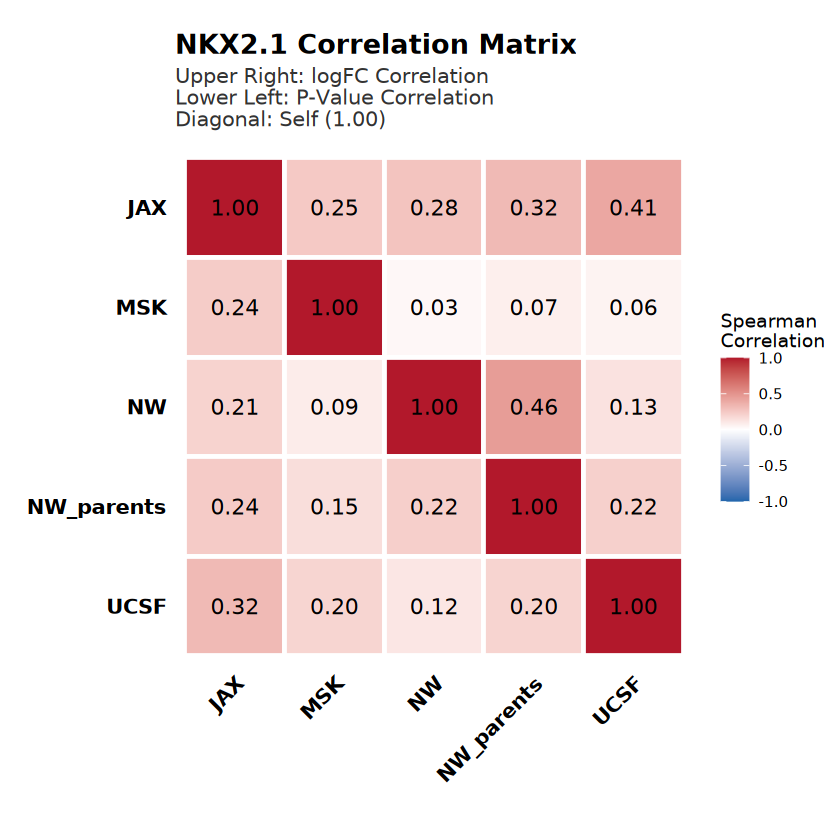

In [38]:
# 1. Put all your dataframes into a named list
# Make sure your 5 dataframes are named accordingly in your environment
df_list <- list(
  JAX = ttJAX,
  MSK = ttMSK,
  NW = ttNW_dmso,
  NW_parents = ttNW,
  UCSF = ttUCSF
)

# 2. Find the common genes across all 5 datasets
# Assuming your gene names are the row names (as shown in your ttJAX snippet)
common_genes <- Reduce(intersect, lapply(df_list, rownames))

# Optional: If your gene names are actually in a column named 'V1', use this instead:
# common_genes <- Reduce(intersect, lapply(df_list, function(x) x$V1))

# 3. Extract the logFC and P.Value for these common genes
logFC_matrix <- sapply(df_list, function(df) df[common_genes, "logFC"])
pval_matrix  <- sapply(df_list, function(df) df[common_genes, "P.Value"])

# 4. Calculate the correlation matrices
# Note: "pearson" is standard, but you can change to "spearman" if you want rank-based correlation
cor_logFC <- cor(logFC_matrix, method = "spearman", use = "pairwise.complete.obs")
cor_pval  <- cor(pval_matrix, method = "spearman", use = "pairwise.complete.obs")

# 5. Initialize the combined matrix with 1s on the diagonal
n_datasets <- length(df_list)
combined_matrix <- matrix(1, nrow = n_datasets, ncol = n_datasets)
rownames(combined_matrix) <- names(df_list)
colnames(combined_matrix) <- names(df_list)

# 6. Fill the Upper Triangle with logFC correlations
combined_matrix[upper.tri(combined_matrix)] <- cor_logFC[upper.tri(cor_logFC)]

# 7. Fill the Lower Triangle with P.Value correlations
combined_matrix[lower.tri(combined_matrix)] <- cor_pval[lower.tri(cor_pval)]

# Print the final matrix
print(combined_matrix)

# --- Heatmap Visualization ---

# 1. Convert the matrix into a long-format dataframe suitable for ggplot
cor_df <- as.data.frame(as.table(combined_matrix))
colnames(cor_df) <- c("Dataset1", "Dataset2", "Correlation")

# 2. Reverse the factor order of Dataset1 so the diagonal goes from top-left to bottom-right
cor_df$Dataset1 <- factor(cor_df$Dataset1, levels = rev(rownames(combined_matrix)))
cor_df$Dataset2 <- factor(cor_df$Dataset2, levels = colnames(combined_matrix))

# 3. Create the Heatmap using ggplot2
plot_heatmap <- ggplot(data = cor_df, aes(x = Dataset2, y = Dataset1, fill = Correlation)) +
  geom_tile(color = "white", size = 1) +
  
  # Red/Blue color gradient (Standard for correlations: Red = +1, Blue = -1)
  scale_fill_gradient2(low = "#2166AC", mid = "white", high = "#B2182B", 
                       midpoint = 0, limit = c(-1, 1), name = "Spearman\nCorrelation") +
  
  # Add the correlation numbers inside the boxes (rounded to 2 decimal places)
  geom_text(aes(label = sprintf("%.2f", Correlation)), color = "black", size = 4.5) +
  
  # Clean minimal theme
  theme_minimal() +
  coord_fixed() + # Keeps the tiles perfectly square
  
  # Labels and Title (Explaining Upper vs Lower)
  labs(
    title = "NKX2.1 Correlation Matrix",
    subtitle = "Upper Right: logFC Correlation\nLower Left: P-Value Correlation\nDiagonal: Self (1.00)",
    x = "",
    y = ""
  ) +
  
  # Theme adjustments for font sizes and angles
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 12, face = "bold", color="black"),
    axis.text.y = element_text(size = 12, face = "bold", color="black"),
    panel.grid.major = element_blank(), # Remove grid lines
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "gray20", margin = margin(b=10))
  )

# Display the plot
print(plot_heatmap)

# --- Optional: Save the plot ---
ggsave(
  filename = file.path(personal_path, paste0("publication/", "NKX2.1_Correlation_Heatmap.png")),
  plot     = plot_heatmap,
  device   = ragg::agg_png,
  bg       = "white",
  width    = 1800,
  height   = 1600,
  units    = "px",
  dpi      = 300
)
